# 23_OP-Cris: Flujo Completo para PDF/CDF y Pricing con Fourier

## 1) Generación de datos Black-Scholes

Este notebook parte del modelo de Black-Scholes:

$$
dS_t = r S_t\,dt + \sigma S_t\,dB_t
$$

En las primeras celdas se fijan parámetros de mercado y simulación:

- `S0 = 100.0`
- `r = 0.10`
- `sigma = 0.25`
- `T = 1.0`
- `num_samples = 2500`
- `test_points = 100`

Se genera la variable:

$$
X_T = \log(S_T / K)
$$

y su versión reescalada para el circuito cuántico en $-\pi, \pi$.

En la parte inicial se usa $K=100$; en el experimento final multi-strike se usan $K \in \{90,100,110\}$.


In [ ]:
import numpy as np

# 1. Market and Model Parameters
S0 = 100.0  # Initial stock price
r = 0.1  # Risk-free interest rate
T = 1.0  # Time to maturity
sigma = 0.25  # Volatility
K = 100.0  # Strike price

# 2. Simulation Settings
num_samples = 2500
test_points = 100


def simulate_black_scholes_data(S0, r, T, sigma, K, n):
    # Generate random normal variables
    Z = np.random.standard_normal(n)

    # Calculate ST using the exact solution
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    # 3. Logarithmic normalization
    # Xt = log(St/K)
    XT = np.log(ST / K)

    # 4. Rescaling to [-pi, pi] for the PQC
    # We first find the min/max of the generated XT to map it
    x_min, x_max = np.min(XT), np.max(XT)
    XT_rescaled = 2 * np.pi * (XT - x_min) / (x_max - x_min) - np.pi

    return XT, XT_rescaled


# Generate the data
raw_log_prices, training_inputs = simulate_black_scholes_data(S0, r, T, sigma, K, num_samples)


# For Method I: You would also need the true PDF values
def normal_pdf(x, S0, K, r, sigma, T):
    mean = np.log(S0 / K) + (r - 0.5 * sigma**2) * T
    std = sigma * np.sqrt(T)
    return (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)    


pdf_labels = normal_pdf(raw_log_prices, S0, K, r, sigma, T)


# For Method II: The model uses the empirical CDF (self-supervised)
def empirical_cdf(x, data):
    return np.array([np.mean(data <= val) for val in x])


# Example output
print(f"First 5 training inputs (rescaled): {training_inputs[:5]}")

First 5 training inputs (rescaled): [ 0.40002806 -0.30234666 -1.09575917 -0.35811262 -1.03839244]


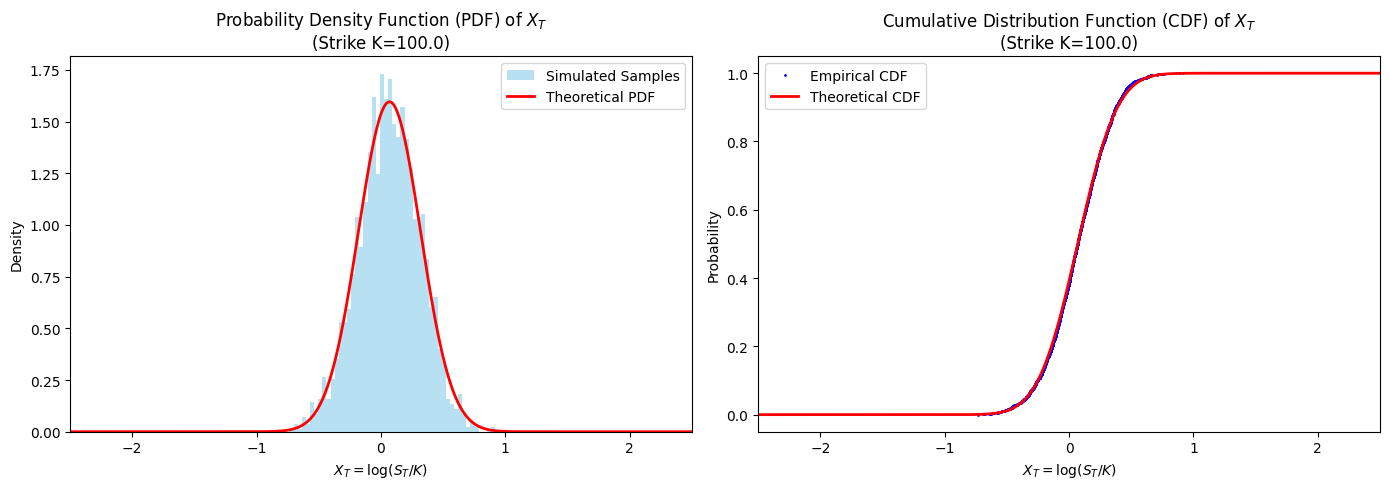

In [15]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Calculate theoretical parameters for Xt
mean_xt = np.log(S0 / K) + (r - 0.5 * sigma**2) * T
std_xt = sigma * np.sqrt(T)

# Generate points for theoretical curves
x_axis = np.linspace(-2.5, 2.5, 500)
theoretical_pdf = stats.norm.pdf(x_axis, mean_xt, std_xt)
theoretical_cdf = stats.norm.cdf(x_axis, mean_xt, std_xt)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PDF and Histogram
ax1.hist(raw_log_prices, bins=50, density=True, alpha=0.6, color="skyblue", label="Simulated Samples")
ax1.plot(x_axis, theoretical_pdf, "r-", lw=2, label="Theoretical PDF")
ax1.set_title(f"Probability Density Function (PDF) of $X_T$\n(Strike K={K})")
ax1.set_xlabel(r"$X_T = \log(S_T/K)$")
ax1.set_ylabel("Density")
ax1.set_xlim(-2.5, 2.5)
ax1.legend()

# Plot 2: CDF
# Empirical CDF calculation
sorted_data = np.sort(raw_log_prices)
y_values = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

ax2.plot(sorted_data, y_values, "b.", markersize=2, label="Empirical CDF")
ax2.plot(x_axis, theoretical_cdf, "r-", lw=2, label="Theoretical CDF")
ax2.set_title(f"Cumulative Distribution Function (CDF) of $X_T$\n(Strike K={K})")
ax2.set_xlabel(r"$X_T = \log(S_T/K)$")
ax2.set_ylabel("Probability")
ax2.set_xlim(-2.5, 2.5)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
def get_analytical_put_payoff_coeffs(K, a, b, K_terms):
    # L is the length of the truncation interval
    L = b - a
    C_k = np.zeros(K_terms + 1)
    D_k = np.zeros(K_terms + 1)

    for k in range(K_terms + 1):
        omega = (2 * np.pi * k) / L

        # 1. Integral of the constant term K from a to 0
        if k == 0:
            int_const = K * (0 - a)
        else:
            # Integral of K * cos(omega * (y - a))
            int_const = (K / omega) * (np.sin(omega * (0 - a)) - np.sin(omega * (a - a)))

        # 2. Integral of the exponential term K * exp(y) from a to 0
        # This uses the identity: integral of exp(y)*cos(omega*(y-a))
        # Result: [exp(y)/(1+omega^2) * (cos(omega(y-a)) + omega*sin(omega(y-a)))]
        phi_0 = omega * (0 - a)
        phi_a = omega * (a - a)

        val_0 = (1 / (1 + omega**2)) * (np.cos(phi_0) + omega * np.sin(phi_0))
        val_a = (np.exp(a) / (1 + omega**2)) * (np.cos(phi_a) + omega * np.sin(phi_a))
        int_exp = K * (val_0 - val_a)

        # Payoff coefficients
        C_k[k] = (2 / L) * (int_const - int_exp)
        # For Put options, D_k is derived similarly with sine terms

    return C_k


# Define your truncation interval based on your simulated data
a = np.min(raw_log_prices)
b = np.max(raw_log_prices)
K_terms = 6  # Example: 6x6 scheme used in Method I

payoff_coeffs = get_analytical_put_payoff_coeffs(K, a, b, K_terms)
print(f"Analytical Payoff Coeffs (C_k): {payoff_coeffs}")

Analytical Payoff Coeffs (C_k): [25.98528486 11.82139163 -0.77110971  0.98137179  0.11931808  0.12448374
  0.21475856]


In [17]:
payoff_coeffs.size

7

## 2) Bloque de funciones: labels, losses y workflow cuántico

Este bloque valida el pipeline de forma incremental con datos analíticos de Black-Scholes.

Qué se hace:

- Se construyen etiquetas analíticas de `cdf`, `pdf` y `d(pdf)/dS`.
- Se evalúan dos funciones de pérdida:
  - `loss_function_qdml` (referencia legacy).
  - `loss_function_pdf_and_derivative` con `loss_weights=(0.9, 0.1, 0.0)`.
- Se ejecuta un workflow cuántico opcional (`RUN_QUANTUM_WORKFLOW_EXAMPLE=True`) para predecir `pdf` y su derivada.

Configuración cuántica actual del ejemplo:

- `n_qubits_by_feature = 6`
- `n_layers = 6`
- `nbshots = 0` (simulación determinista del observable)

Objetivo de esta sección: comprobar que las piezas (datos, pérdidas, workflow y salida) son coherentes antes de pasar al pricing por Fourier.


In [18]:
from pathlib import Path
import sys
import numpy as np

# Make imports robust whether notebook is launched from repo root or this folder
cwd = Path.cwd().resolve()
fa_root = None
for p in [cwd, *cwd.parents]:
    if (p / 'QQuantLib').exists() and (p / 'misc').exists():
        fa_root = p
        break
    if (p / 'FinancialApplications' / 'QQuantLib').exists():
        fa_root = p / 'FinancialApplications'
        break

if fa_root is None:
    raise RuntimeError('Could not locate FinancialApplications root')

sys.path.insert(0, str(fa_root))

from QQuantLib.qml4var.data_utils import bs_pdf, bs_cdf
from misc.CrisTFM.functions import (
    loss_function_qdml,
    loss_function_pdf_and_derivative,
    workflow_for_pdf_and_derivative_cris,
    complex_fourier_coefficients,
    ak_bk_from_complex_coefficients,
    fourier_price_v_t0,
)


In [19]:
# 1) Build Black-Scholes dataset for S_T
S0 = 100.0
r = 0.10
sigma = 0.25
T = 1.0

s_grid = np.linspace(40.0, 180.0, 350)
labels_cdf = bs_cdf(s_grid, s_0=S0, risk_free_rate=r, volatility=sigma, maturity=T).reshape(-1, 1)
labels_pdf = bs_pdf(s_grid, s_0=S0, risk_free_rate=r, volatility=sigma, maturity=T).reshape(-1, 1)

# Analytical derivative of lognormal pdf wrt S
mu = (r - 0.5 * sigma * sigma) * T + np.log(S0)
var = sigma * sigma * T
log_term = np.log(s_grid) - mu
labels_pdf_derivative = (labels_pdf[:, 0] * (-1.0 / s_grid - log_term / (var * s_grid))).reshape(-1, 1)

print('Dataset shapes:')
print('labels_cdf            ', labels_cdf.shape)
print('labels_pdf            ', labels_pdf.shape)
print('labels_pdf_derivative ', labels_pdf_derivative.shape)


Dataset shapes:
labels_cdf             (350, 1)
labels_pdf             (350, 1)
labels_pdf_derivative  (350, 1)


In [20]:
# 2) Example use of the implemented losses with BS-generated labels
rng = np.random.default_rng(1234)
predict_cdf = labels_cdf + rng.normal(0.0, 5e-4, size=labels_cdf.shape)
predict_pdf = labels_pdf + rng.normal(0.0, 5e-4, size=labels_pdf.shape)
predict_pdf_derivative = labels_pdf_derivative + rng.normal(0.0, 5e-4, size=labels_pdf_derivative.shape)

trapz_fn = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
integral_pdf_sq = trapz_fn(y=predict_pdf[:, 0] ** 2, x=s_grid)

loss_qdml_value = loss_function_qdml(
    labels=labels_cdf,
    predict_cdf=predict_cdf,
    predict_pdf=predict_pdf,
    integral=integral_pdf_sq,
)

loss_pdf_derivative_value = loss_function_pdf_and_derivative(
    labels_pdf=labels_pdf,
    predict_pdf=predict_pdf,
    predict_pdf_derivative=predict_pdf_derivative,
    labels_pdf_derivative=labels_pdf_derivative,
    integral_pdf_sq=integral_pdf_sq,
    loss_weights=(0.9, 0.1, 0.0),
)

print(f'loss_function_qdml: {loss_qdml_value:.8f}')
print(f'loss_function_pdf_and_derivative: {loss_pdf_derivative_value:.8f}')


loss_function_qdml: -0.00163047
loss_function_pdf_and_derivative: 0.00000025


In [ ]:
RUN_QUANTUM_WORKFLOW_EXAMPLE = True
AUTO_BUILD_QUANTUM_CONFIG = True

if RUN_QUANTUM_WORKFLOW_EXAMPLE:
    if AUTO_BUILD_QUANTUM_CONFIG:
        from QQuantLib.qml4var.architectures import (
            hardware_efficient_ansatz,
            z_observable,
            normalize_data,
        )
        from QQuantLib.qml4var.data_utils import bs_pdf

        # Use existing BS parameters if already defined in notebook, otherwise defaults
        S0_ = float(globals().get('S0', 100.0))
        r_ = float(globals().get('r', 0.10))
        sigma_ = float(globals().get('sigma', 0.25))
        T_ = float(globals().get('T', 1.0))

        if 's_grid' not in globals():
            s_grid = np.linspace(40.0, 180.0, 350)

        data_x = np.asarray(s_grid).reshape(-1, 1)

        # Black-Scholes labels for PDF and derivative(PDF)
        labels_pdf_data = bs_pdf(
            data_x[:, 0], s_0=S0_, risk_free_rate=r_, volatility=sigma_, maturity=T_
        ).reshape(-1, 1)

        mu_ = (r_ - 0.5 * sigma_ * sigma_) * T_ + np.log(S0_)
        var_ = sigma_ * sigma_ * T_
        log_term_ = np.log(data_x[:, 0]) - mu_
        labels_pdf_derivative_data = (
            labels_pdf_data[:, 0] * (-1.0 / data_x[:, 0] - log_term_ / (var_ * data_x[:, 0]))
        ).reshape(-1, 1)

        # Minimal quantum setup for qml4var workflows
        slope, shift = normalize_data(
            min_value=[float(data_x.min())],
            max_value=[float(data_x.max())],
            min_x=[-0.5 * np.pi],
            max_x=[0.5 * np.pi],
        )

        pqc, weights_names, features_names = hardware_efficient_ansatz(
            features_number=1,
            n_qubits_by_feature=6,
            n_layers=6,
            base_frecuency=slope,
            shift_feature=shift,
        )
        observable = z_observable(features_number=1, n_qubits_by_feature=6)
        weights = np.zeros(len(weights_names))
        qpu_info = {'qpu_type': 'python'}

    output = workflow_for_pdf_and_derivative_cris(
        weights=weights,
        data_x=data_x,
        labels_pdf=labels_pdf_data,
        labels_pdf_derivative=labels_pdf_derivative_data,
        pqc=pqc,
        observable=observable,
        weights_names=weights_names,
        features_names=features_names,
        nbshots=0,
        qpu_info=qpu_info,
        pdf_derivative_features=[features_names[0]],
    )

    workflow_loss = loss_function_pdf_and_derivative(
        labels_pdf=output['labels_pdf'],
        predict_pdf=output['predict_pdf'],
        predict_pdf_derivative=output['predict_pdf_derivative'],
        labels_pdf_derivative=output.get('labels_pdf_derivative'),
        loss_weights=(0.9, 0.1, 0.0),
    )

    print('workflow output keys:', list(output.keys()))
    print('predict_pdf shape:', output['predict_pdf'].shape)
    print('predict_pdf_derivative shape:', output['predict_pdf_derivative'].shape)
    print('workflow loss:', float(workflow_loss))
else:
    print('Set RUN_QUANTUM_WORKFLOW_EXAMPLE=True to execute the quantum workflow example.')


workflow output keys: ['predict_pdf', 'predict_pdf_derivative', 'labels_pdf', 'labels_pdf_derivative']
predict_pdf shape: (350, 1)
predict_pdf_derivative shape: (350, 1)
workflow loss: 0.0022313721939302704


In [22]:
# 4) Compute c_k -> A_k^f, B_k^f from PDF
if 'output' in globals() and isinstance(output, dict) and 'predict_pdf' in output and 'data_x' in globals():
    x_fourier = np.asarray(data_x[:, 0]).reshape(-1)
    pdf_for_fourier = np.asarray(output['predict_pdf']).reshape(-1)
    pdf_source = 'quantum workflow prediction'
elif 'labels_pdf' in globals() and 's_grid' in globals():
    x_fourier = np.asarray(s_grid).reshape(-1)
    pdf_for_fourier = np.asarray(labels_pdf).reshape(-1)
    pdf_source = 'Black-Scholes analytical pdf'
elif 'labels_pdf_data' in globals() and 'data_x' in globals():
    x_fourier = np.asarray(data_x[:, 0]).reshape(-1)
    pdf_for_fourier = np.asarray(labels_pdf_data).reshape(-1)
    pdf_source = 'Black-Scholes labels from quantum setup'
else:
    raise RuntimeError('No PDF data found. Run previous cells first.')

K_fourier = 20
a_fourier = float(np.min(x_fourier))
b_fourier = float(np.max(x_fourier))

k_vals, c_k = complex_fourier_coefficients(
    x_domain=x_fourier,
    y_predict=pdf_for_fourier,
    k_values=K_fourier,
    interval=(a_fourier, b_fourier),
)
k_pos, A_k_f, B_k_f = ak_bk_from_complex_coefficients(k_vals, c_k, k_max=K_fourier)

print('PDF source:', pdf_source)
print('k range:', int(k_vals.min()), 'to', int(k_vals.max()))
print('A_k^f shape:', A_k_f.shape, 'B_k^f shape:', B_k_f.shape)
print('First coefficients:')
for i in range(min(5, len(k_pos))):
    print(f'k={k_pos[i]:2d} | A={A_k_f[i]} | B={B_k_f[i]}')


PDF source: quantum workflow prediction
k range: -20 to 20
A_k^f shape: (21,) B_k^f shape: (21,)
First coefficients:
k= 0 | A=(-0.028564675247037735+0j) | B=-0j
k= 1 | A=(-0.031640142064535935+0j) | B=(-0.01048093974062052+0j)
k= 2 | A=(-0.029919473645037466+0j) | B=(0.03011945439110324-0j)
k= 3 | A=(-0.0008266868767225932+0j) | B=(-0.02561703514376255+0j)
k= 4 | A=(0.010039544566039005+0j) | B=(0.01352688111680281-0j)


In [23]:
# 5) Build payoff coefficients C_k, D_k and compute V(t0, x)
L = b_fourier - a_fourier
z = (x_fourier - a_fourier) / L
strike_ = float(globals().get('K', 100.0))
payoff_values = np.maximum(strike_ - x_fourier, 0.0)

trapz_fn = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
C_k = np.zeros(K_fourier + 1, dtype=complex)
D_k = np.zeros(K_fourier + 1, dtype=complex)

for k in range(K_fourier + 1):
    angle = 2.0 * np.pi * k * z
    C_k[k] = (2.0 / L) * trapz_fn(payoff_values * np.cos(angle), x_fourier)
    if k == 0:
        D_k[k] = 0.0
    else:
        D_k[k] = (2.0 / L) * trapz_fn(payoff_values * np.sin(angle), x_fourier)

r_used = float(globals().get('r', globals().get('r_', 0.0)))
delta_t_used = float(globals().get('T', globals().get('T_', 1.0)))

v_t0 = fourier_price_v_t0(
    a=a_fourier,
    b=b_fourier,
    risk_free_rate=r_used,
    delta_t=delta_t_used,
    a_k_f=A_k_f,
    b_k_f=B_k_f,
    c_k_payoff=C_k,
    d_k_payoff=D_k,
)

# Direct discounted integral as a numerical reference
direct_price = np.exp(-r_used * delta_t_used) * trapz_fn(payoff_values * pdf_for_fourier, x_fourier)

print(f'V(t0,x) Fourier (real): {np.real(v_t0):.10f}')
print(f'V(t0,x) Fourier (imag): {np.imag(v_t0):.3e}')
print(f'Direct integral reference: {direct_price:.10f}')

V(t0,x) Fourier (real): -50.9251669095
V(t0,x) Fourier (imag): 0.000e+00
Direct integral reference: -50.6047283497


## 3) Curva de precio en el dominio `x \in [-15, 15]`

Aquí se calcula la curva `V(t0, x)` en una malla de valores `x` usando la formulación de Fourier.

Procedimiento:

- Se toma una PDF base (predicha o analítica, según celdas previas).
- Se reescala su dominio al intervalo de visualización `[-15, 15]`.
- Se reconstruyen coeficientes de Fourier sobre ese dominio.
- Se calcula el precio por dos vías:
  - Aproximación de Fourier.
  - Integral directa descontada (referencia numérica).

La figura compara ambas curvas para validar consistencia numérica y detectar sesgos de truncación/discretización.


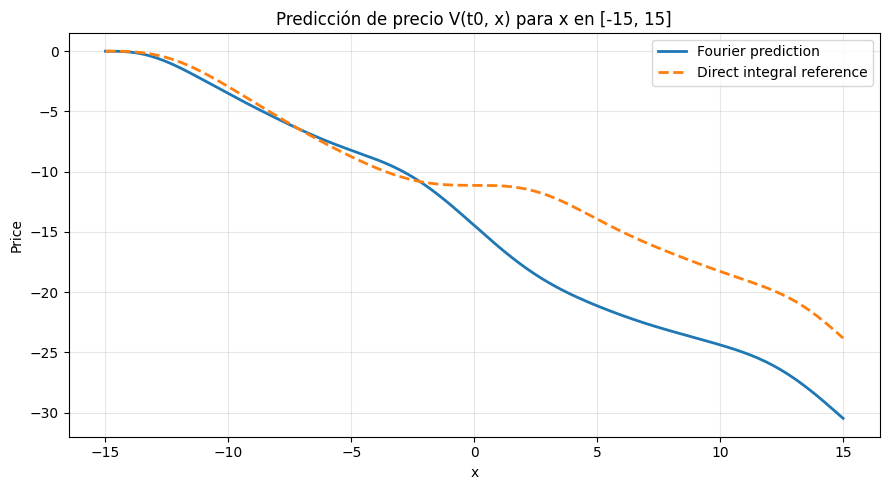

Dominio original PDF: (40.0, 180.0)
Dominio usado para la gráfica: (-15.0, 15.0)


In [24]:
# 6) Price prediction curve V(t0, x) for x in [-15, 15]
if 'x_fourier' not in globals() or 'pdf_for_fourier' not in globals():
    raise RuntimeError('Run Fourier coefficient cells first (cells 10 and 11).')

x_min_plot, x_max_plot = -15.0, 15.0
x_price_grid = np.linspace(x_min_plot, x_max_plot, 201)
trapz_fn = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

# Rescale original PDF domain to the requested plotting interval [-15, 15]
a_orig = float(np.min(x_fourier))
b_orig = float(np.max(x_fourier))
if b_orig <= a_orig:
    raise ValueError('Invalid original domain for x_fourier')

x_pdf_plot = x_min_plot + (x_fourier - a_orig) * (x_max_plot - x_min_plot) / (b_orig - a_orig)
jacobian_dy_dx = (b_orig - a_orig) / (x_max_plot - x_min_plot)
pdf_plot = pdf_for_fourier * jacobian_dy_dx

# Recompute c_k -> A_k^f, B_k^f on the plotting domain
k_vals_plot, c_k_plot = complex_fourier_coefficients(
    x_domain=x_pdf_plot,
    y_predict=pdf_plot,
    k_values=K_fourier,
    interval=(x_min_plot, x_max_plot),
)
_, A_k_plot, B_k_plot = ak_bk_from_complex_coefficients(
    k_vals_plot, c_k_plot, k_max=K_fourier
)

price_fourier_curve = np.zeros_like(x_price_grid, dtype=float)
price_direct_curve = np.zeros_like(x_price_grid, dtype=float)

L_plot = x_max_plot - x_min_plot
z_plot = (x_pdf_plot - x_min_plot) / L_plot

for idx, x_eval in enumerate(x_price_grid):
    # Put-like payoff in the plotting variable
    payoff_eval = np.maximum(x_eval - x_pdf_plot, 0.0)

    C_eval = np.zeros(K_fourier + 1, dtype=complex)
    D_eval = np.zeros(K_fourier + 1, dtype=complex)
    for k in range(K_fourier + 1):
        angle = 2.0 * np.pi * k * z_plot
        C_eval[k] = (2.0 / L_plot) * trapz_fn(payoff_eval * np.cos(angle), x_pdf_plot)
        if k == 0:
            D_eval[k] = 0.0
        else:
            D_eval[k] = (2.0 / L_plot) * trapz_fn(payoff_eval * np.sin(angle), x_pdf_plot)

    v_eval = fourier_price_v_t0(
        a=x_min_plot,
        b=x_max_plot,
        risk_free_rate=r_used,
        delta_t=delta_t_used,
        a_k_f=A_k_plot,
        b_k_f=B_k_plot,
        c_k_payoff=C_eval,
        d_k_payoff=D_eval,
    )
    price_fourier_curve[idx] = float(np.real(v_eval))

    direct_eval = np.exp(-r_used * delta_t_used) * trapz_fn(payoff_eval * pdf_plot, x_pdf_plot)
    price_direct_curve[idx] = float(np.real(direct_eval))

plt.figure(figsize=(9, 5))
plt.plot(x_price_grid, price_fourier_curve, label='Fourier prediction', linewidth=2)
plt.plot(x_price_grid, price_direct_curve, '--', label='Direct integral reference', linewidth=2)
plt.title('Predicción de precio V(t0, x) para x en [-15, 15]')
plt.xlabel('x')
plt.ylabel('Price')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('Dominio original PDF:', (a_orig, b_orig))
print('Dominio usado para la gráfica:', (x_min_plot, x_max_plot))


## 4) Distribución de $X_T$: teórica vs simulada

Esta sección contrasta la simulación Monte Carlo con la distribución normal teórica de Black-Scholes para:

$$
X_T = \log(S_T/K)
$$

Se muestran dos paneles:

- PDF:
  - Histograma de muestras simuladas.
  - PDF simulada suavizada mediante KDE.
  - PDF teórica normal.
- CDF:
  - CDF empírica de las muestras.
  - CDF teórica normal.

Además se marcan cuantiles `P25`, `P50` (mediana) y `P75` para comparar posición central y dispersión entre simulación y teoría.

Nota: el eje `x` se fija en `[-2.5, 2.5]` para mantener comparabilidad visual.


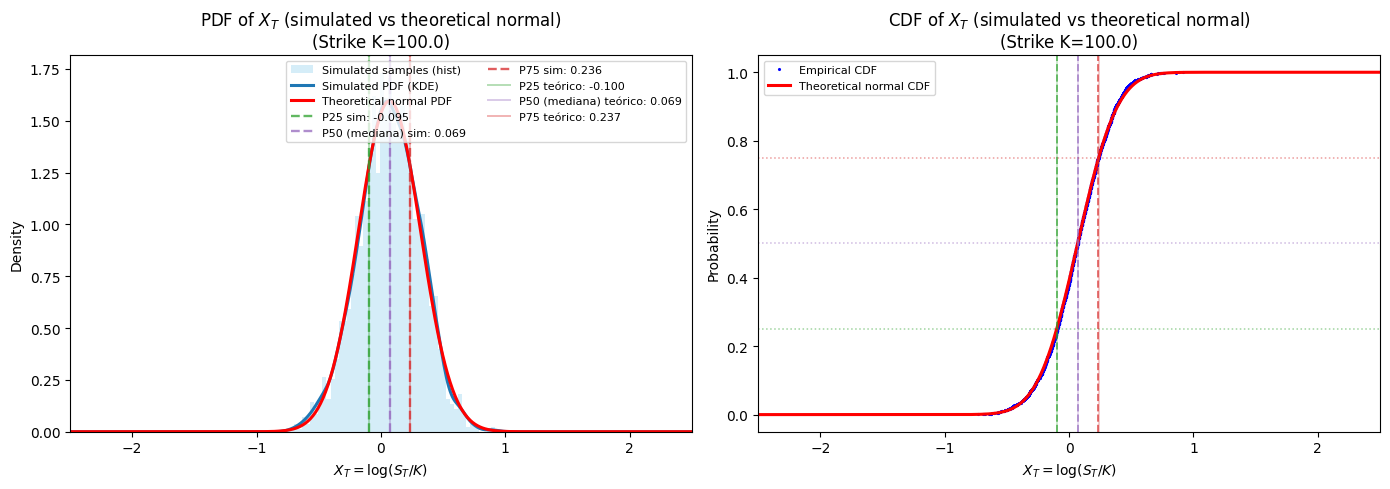

Simulated quantiles [P25, P50, P75]: [-0.09530191  0.06884427  0.23635739]
Theoretical quantiles[P25, P50, P75]: [-0.09987244  0.06875     0.23737244]


In [25]:
# 7) Normal theoretical distribution of Xt vs simulated samples + quantiles
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

if 'raw_log_prices' not in globals():
    raise RuntimeError('raw_log_prices not found. Run cell 1 first.')
if any(v not in globals() for v in ['S0', 'K', 'r', 'sigma', 'T']):
    raise RuntimeError('Missing S0/K/r/sigma/T. Run cell 1 first.')

# Theoretical parameters of Xt under Black-Scholes
mean_xt = np.log(S0 / K) + (r - 0.5 * sigma**2) * T
std_xt = sigma * np.sqrt(T)

# Plot grid for theoretical/simulated curves
x_axis = np.linspace(-2.5, 2.5, 500)
theoretical_pdf = stats.norm.pdf(x_axis, mean_xt, std_xt)
theoretical_cdf = stats.norm.cdf(x_axis, mean_xt, std_xt)

# Simulated PDF (smoothed empirical density via KDE)
simulated_kde = stats.gaussian_kde(raw_log_prices)
simulated_pdf = simulated_kde(x_axis)

# Empirical CDF from simulated samples
sorted_data = np.sort(raw_log_prices)
y_values = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

# Quantiles: simulated vs theoretical
probs = np.array([0.25, 0.5, 0.75])
q_labels = ["P25", "P50 (mediana)", "P75"]
q_colors = ["#2ca02c", "#9467bd", "#d62728"]
q_sim = np.quantile(raw_log_prices, probs)
q_theo = stats.norm.ppf(probs, loc=mean_xt, scale=std_xt)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PDF + histogram
ax1.hist(raw_log_prices, bins=50, density=True, alpha=0.35, color="skyblue", label="Simulated samples (hist)")
ax1.plot(x_axis, simulated_pdf, color="#1f77b4", lw=2.2, label="Simulated PDF (KDE)")
ax1.plot(x_axis, theoretical_pdf, "r-", lw=2.2, label="Theoretical normal PDF")
for qv, lbl, col in zip(q_sim, q_labels, q_colors):
    ax1.axvline(qv, color=col, linestyle="--", linewidth=1.7, alpha=0.75, label=f"{lbl} sim: {qv:.3f}")
for qv, lbl, col in zip(q_theo, q_labels, q_colors):
    ax1.axvline(qv, color=col, linestyle="-", linewidth=1.4, alpha=0.35, label=f"{lbl} teórico: {qv:.3f}")
ax1.set_title(f"PDF of $X_T$ (simulated vs theoretical normal)\n(Strike K={K})")
ax1.set_xlabel(r"$X_T = \log(S_T/K)$")
ax1.set_ylabel("Density")
ax1.set_xlim(-2.5, 2.5)
ax1.legend(fontsize=8, ncol=2)

# Plot 2: CDF empirical vs theoretical
ax2.plot(sorted_data, y_values, "b.", markersize=2.5, label="Empirical CDF")
ax2.plot(x_axis, theoretical_cdf, "r-", lw=2.2, label="Theoretical normal CDF")
for qv, p, col in zip(q_sim, probs, q_colors):
    ax2.axvline(qv, color=col, linestyle="--", linewidth=1.4, alpha=0.65)
    ax2.axhline(p, color=col, linestyle=":", linewidth=1.1, alpha=0.45)
for qv, p, col in zip(q_theo, probs, q_colors):
    ax2.axvline(qv, color=col, linestyle="-", linewidth=1.1, alpha=0.30)
ax2.set_title(f"CDF of $X_T$ (simulated vs theoretical normal)\n(Strike K={K})")
ax2.set_xlabel(r"$X_T = \log(S_T/K)$")
ax2.set_ylabel("Probability")
ax2.set_xlim(-2.5, 2.5)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Simulated quantiles [P25, P50, P75]:", q_sim)
print("Theoretical quantiles[P25, P50, P75]:", q_theo)


## 5) Experimento principal: multi-strike, tamaño de dataset y barrido KDE

Este es el bloque principal de robustez del pricing.

Diseño experimental:

- Intervalo de trabajo del modelo: `[-2\pi, 2\pi]`.
- Datos reescalados: `[-\pi, \pi]`.
- Strikes: `[90, 100, 110]`.
- Tamaños de entrenamiento: `[250, 500, 1000, 2500]`.
- Repeticiones por configuración: `10`.
- Fourier: `k_terms=12`, `grid_points=1024`.
- KDE bandwidth sweep: `['scott', 'silverman', 0.7, 1.0, 1.3]`.

Qué se mide:

- Precio estimado (train/test) por configuración.
- `abs_train_test_gap = |price_train - price_test|` como métrica de estabilidad/generalización.

Qué se grafica:

- Ranking del impacto de `bw_method` en el error.
- Precio medio con barras de desviación estándar por `strike` y `dataset_size`.
- Gap train-test medio (con error bars) por `strike` y `dataset_size`.

Interpretación práctica: menor `train-test gap` y menor dispersión suelen indicar una estimación de PDF más estable para el pricing.


Theoretical BS put prices: {90: 2.5988266, 100: 5.45953258, 110: 9.69216835}
Using data interval ~[-pi, pi] and train interval = (-6.283185307179586, 6.283185307179586)
Using test_points = 100
KDE bandwidth ranking (by mean abs train-test gap):
                 mean       std
bw_method                      
factor_1.00  0.783204  0.677180
scott        0.795876  0.750116
silverman    0.810520  0.649998
factor_0.70  0.821382  0.685946
factor_1.30  0.910969  0.711069
Selected bw_method for detailed plots: factor_1.00
Mean abs train-test gap by bw_method and strike:
strike            90        100       110
bw_method                                
scott        0.781974  0.824735  0.780917
silverman    0.591714  0.787092  1.052753
factor_0.70  0.645252  0.948697  0.870198
factor_1.00  0.577530  0.799337  0.972746
factor_1.30  0.633027  0.923485  1.176394


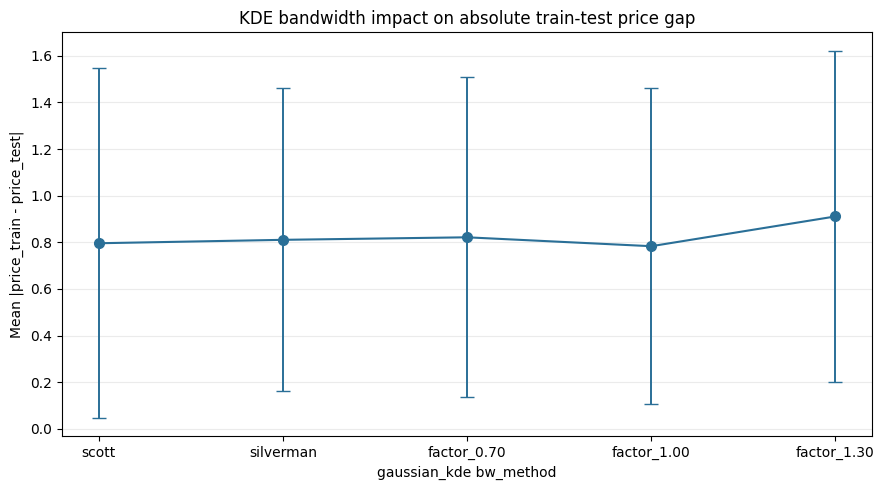

                          mean       std       min        max     median
strike dataset_size                                                     
90     250            6.137273  2.636977  1.491535   9.672785   6.429305
       500            6.189354  2.128454  1.617182   8.806896   6.368576
       1000           5.704682  3.463690  2.164271  11.640754   4.061657
       2500           4.901769  1.924399  2.398427   7.690698   4.418545
100    250            7.165387  2.707760  3.686155  11.000657   7.083093
       500           10.887942  5.297742  4.206308  20.003029   9.848511
       1000           7.230616  2.733009  3.440314  12.217652   7.078666
       2500           9.350853  4.254810  3.254617  18.953463   8.344782
110    250           16.608217  5.718384  9.120000  25.978251  15.063868
       500           10.949902  4.560382  4.803514  20.399535  11.367415
       1000          12.701241  2.899424  9.876249  17.811450  11.735039
       2500          10.961826  3.283607  6.481627 

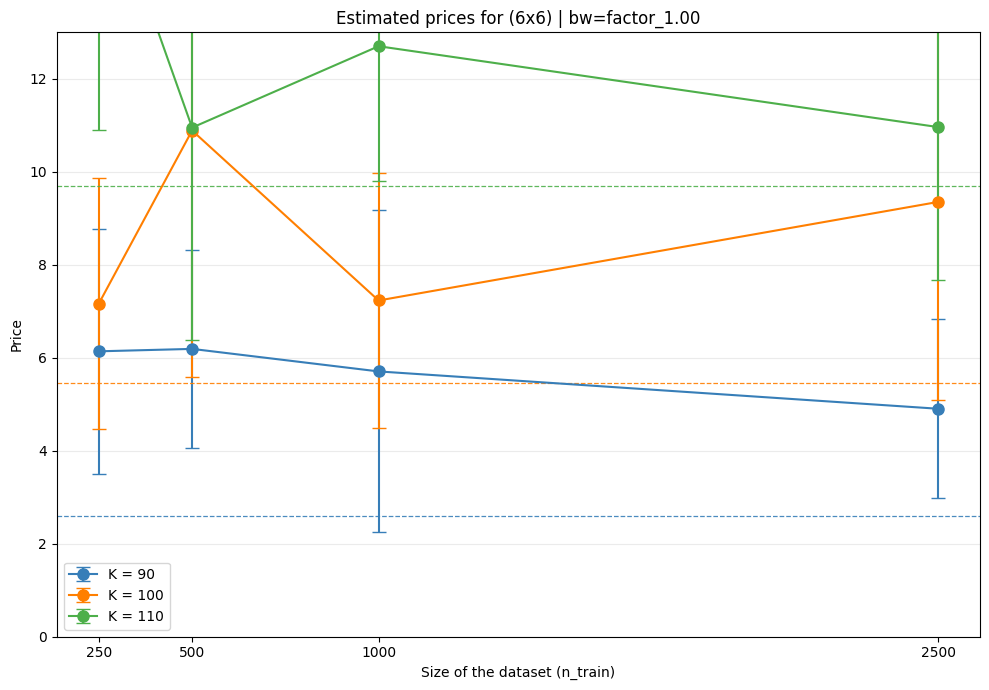

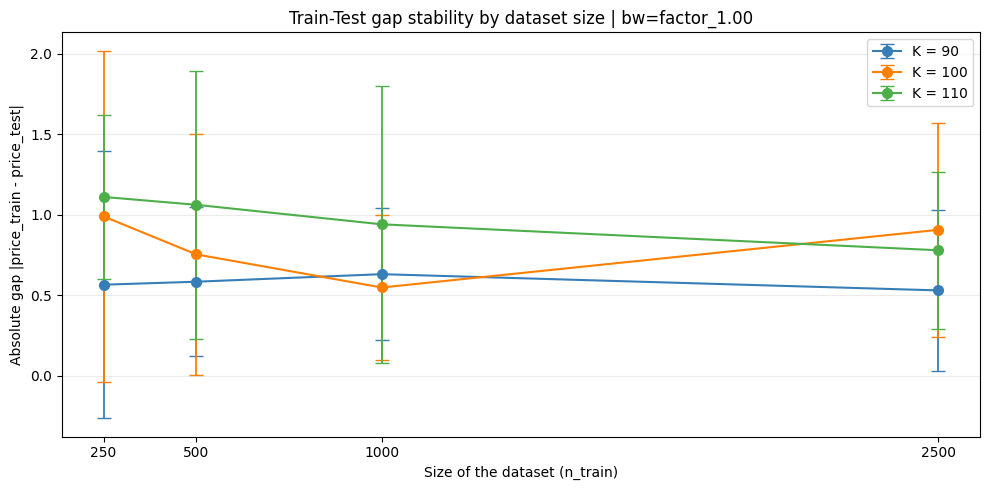

In [ ]:
if any(v not in globals() for v in ['S0', 'r', 'sigma', 'T']):
    raise RuntimeError('Missing S0/r/sigma/T. Run cell 1 first.')
if 'simulate_black_scholes_data' not in globals():
    raise RuntimeError('simulate_black_scholes_data not found. Run cell 1 first.')

test_points = int(globals().get('test_points', 100))
train_interval = (-2.0 * np.pi, 2.0 * np.pi)
data_interval = (-1.0 * np.pi, 1.0 * np.pi)

def bs_put_price(S0_, K_, r_, sigma_, T_):
    d1 = (np.log(S0_ / K_) + (r_ + 0.5 * sigma_**2) * T_) / (sigma_ * np.sqrt(T_))
    d2 = d1 - sigma_ * np.sqrt(T_)
    return K_ * np.exp(-r_ * T_) * stats.norm.cdf(-d2) - S0_ * stats.norm.cdf(-d1)

def inverse_rescaling_u_to_xt(u_values, x_min_raw, x_max_raw):
    u_values = np.asarray(u_values)
    return x_min_raw + (u_values + np.pi) * (x_max_raw - x_min_raw) / (2.0 * np.pi)

def bw_to_label(bw):
    if isinstance(bw, str):
        return bw
    return f'factor_{bw:.2f}'

def estimate_price_fourier_from_rescaled_samples(
        u_samples,
        K_,
        r_,
        T_,
        x_min_raw,
        x_max_raw,
        train_interval_=(-2.0 * np.pi, 2.0 * np.pi),
        k_terms=12,
        grid_points=1024,
        bw_method='scott'):
    u_samples = np.asarray(u_samples).reshape(-1)
    a, b = train_interval_
    if b <= a:
        raise ValueError('Invalid training interval')

    u_grid = np.linspace(a, b, grid_points)
    kde = stats.gaussian_kde(u_samples, bw_method=bw_method)
    pdf_u = kde(u_grid)

    trapz_fn = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
    area = trapz_fn(pdf_u, u_grid)
    if area <= 0:
        raise ValueError('Non-positive PDF area in KDE estimation')
    pdf_u = pdf_u / area

    k_vals, c_k = complex_fourier_coefficients(
        x_domain=u_grid,
        y_predict=pdf_u,
        k_values=k_terms,
        interval=(a, b),
    )
    _, A_k_f, B_k_f = ak_bk_from_complex_coefficients(k_vals, c_k, k_max=k_terms)

    x_raw_grid = inverse_rescaling_u_to_xt(u_grid, x_min_raw, x_max_raw)
    payoff = np.maximum(K_ * (1.0 - np.exp(x_raw_grid)), 0.0)

    L = b - a
    z = (u_grid - a) / L
    C_k = np.zeros(k_terms + 1, dtype=complex)
    D_k = np.zeros(k_terms + 1, dtype=complex)
    for k in range(k_terms + 1):
        angle = 2.0 * np.pi * k * z
        C_k[k] = (2.0 / L) * trapz_fn(payoff * np.cos(angle), u_grid)
        if k == 0:
            D_k[k] = 0.0
        else:
            D_k[k] = (2.0 / L) * trapz_fn(payoff * np.sin(angle), u_grid)

    v_est = fourier_price_v_t0(
        a=a,
        b=b,
        risk_free_rate=r_,
        delta_t=T_,
        a_k_f=A_k_f,
        b_k_f=B_k_f,
        c_k_payoff=C_k,
        d_k_payoff=D_k,
    )
    return float(np.real(v_est))

dataset_sizes = [250, 500, 1000, 2500]
strikes = [90, 100, 110]
colors = ['#377eb8', '#ff7f00', '#4daf4a']
n_repetitions = 10
k_terms = 12
grid_points = 1024
bw_methods = ['scott', 'silverman', 0.7, 1.0, 1.3]

np.random.seed(2026)
records = []

for bw in bw_methods:
    bw_label = bw_to_label(bw)
    for K_ in strikes:
        for n_train in dataset_sizes:
            for rep in range(n_repetitions):
                total_points = n_train + test_points
                xt_all, u_all = simulate_black_scholes_data(S0, r, T, sigma, K_, total_points)

                u_train = u_all[:n_train]
                u_test = u_all[n_train:]

                x_min_raw = float(np.min(xt_all))
                x_max_raw = float(np.max(xt_all))

                price_train = estimate_price_fourier_from_rescaled_samples(
                    u_samples=u_train,
                    K_=K_,
                    r_=r,
                    T_=T,
                    x_min_raw=x_min_raw,
                    x_max_raw=x_max_raw,
                    train_interval_=train_interval,
                    k_terms=k_terms,
                    grid_points=grid_points,
                    bw_method=bw,
                )
                price_test = estimate_price_fourier_from_rescaled_samples(
                    u_samples=u_test,
                    K_=K_,
                    r_=r,
                    T_=T,
                    x_min_raw=x_min_raw,
                    x_max_raw=x_max_raw,
                    train_interval_=train_interval,
                    k_terms=k_terms,
                    grid_points=grid_points,
                    bw_method=bw,
                )

                records.append({
                    'bw_method': bw_label,
                    'strike': K_,
                    'dataset_size': n_train,
                    'test_points': test_points,
                    'rep': rep + 1,
                    'estimated_price': price_train,
                    'estimated_price_test': price_test,
                    'abs_train_test_gap': abs(price_train - price_test),
                    'u_train_min': float(np.min(u_train)),
                    'u_train_max': float(np.max(u_train)),
                })

results_df = pd.DataFrame(records)
theoretical_prices = {K_: bs_put_price(S0, K_, r, sigma, T) for K_ in strikes}

# Rank KDE methods by mean train-test gap (lower is better)
bw_ranking = results_df.groupby('bw_method')['abs_train_test_gap'].agg(['mean', 'std']).sort_values('mean')
best_bw = bw_ranking.index[0]

print('Theoretical BS put prices:', {k: round(float(v), 8) for k, v in theoretical_prices.items()})
print('Using data interval ~[-pi, pi] and train interval =', train_interval)
print('Using test_points =', test_points)
print('KDE bandwidth ranking (by mean abs train-test gap):')
print(bw_ranking)
print('Selected bw_method for detailed plots:', best_bw)

bw_order = [bw_to_label(bw) for bw in bw_methods]
bw_gap_summary = (
    results_df.groupby('bw_method')['abs_train_test_gap']
    .agg(['mean', 'std'])
    .reindex(bw_order)
)
bw_gap_by_strike = (
    results_df.groupby(['bw_method', 'strike'])['abs_train_test_gap']
    .mean()
    .unstack('strike')
    .reindex(bw_order)
)
print('Mean abs train-test gap by bw_method and strike:')
print(bw_gap_by_strike)

x_pos = np.arange(len(bw_gap_summary))
plt.figure(figsize=(9, 5))
plt.errorbar(
    x_pos,
    bw_gap_summary['mean'].values,
    yerr=bw_gap_summary['std'].values,
    fmt='o-',
    color='#2a6f97',
    capsize=5,
    markersize=7,
    elinewidth=1.4,
)
plt.xticks(x_pos, bw_gap_summary.index)
plt.title('KDE bandwidth impact on absolute train-test price gap')
plt.xlabel('gaussian_kde bw_method')
plt.ylabel('Mean |price_train - price_test|')
plt.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.show()

results_best = results_df[results_df['bw_method'] == best_bw].copy()
summary = results_best.groupby(['strike', 'dataset_size'])['estimated_price'].agg(['mean', 'std', 'min', 'max', 'median'])
gap_summary = results_best.groupby(['strike', 'dataset_size'])['abs_train_test_gap'].mean().rename('mean_abs_train_test_gap')
print(summary)
print(gap_summary)

plt.figure(figsize=(10, 7))
for K_, color in zip(strikes, colors):
    df_k = results_best[results_best['strike'] == K_]

    means = []
    stds = []
    for n_ in dataset_sizes:
        subset = df_k[df_k['dataset_size'] == n_]['estimated_price']
        means.append(subset.mean())
        stds.append(subset.std())

    plt.errorbar(
        dataset_sizes, means, yerr=stds,
        fmt='-o', color=color, label=f'K = {K_}',
        capsize=5, markersize=8, elinewidth=1.5
    )

    price_teorico = theoretical_prices[K_]
    plt.axhline(price_teorico, color=color, linestyle='--', linewidth=0.9, alpha=0.9)

    for n_ in dataset_sizes:
        subset = df_k[df_k['dataset_size'] == n_]['estimated_price'].values
        q1, q3 = np.percentile(subset, [25, 75])
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        outliers = subset[(subset < low) | (subset > high)]
        if outliers.size > 0:
            plt.scatter(
                np.full(outliers.shape[0], n_),
                outliers,
                marker='x',
                color=color,
                s=45,
                alpha=0.95,
                label=f'Outliers K={K_}' if n_ == dataset_sizes[0] else None
            )

plt.title(f'Estimated prices for (6x6) | bw={best_bw}')
plt.xlabel('Size of the dataset (n_train)')
plt.ylabel('Price')
plt.xticks(dataset_sizes)
plt.ylim(0, 13)
plt.grid(alpha=0.25, axis='y')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Second figure: stability/generalization gap (train vs test)
plt.figure(figsize=(10, 5))
for K_, color in zip(strikes, colors):
    df_k = results_best[results_best['strike'] == K_]
    gap_means = []
    gap_stds = []
    for n_ in dataset_sizes:
        subset_gap = df_k[df_k['dataset_size'] == n_]['abs_train_test_gap']
        gap_means.append(subset_gap.mean())
        gap_stds.append(subset_gap.std())

    plt.errorbar(
        dataset_sizes, gap_means, yerr=gap_stds,
        fmt='-o', color=color, label=f'K = {K_}',
        capsize=5, markersize=7, elinewidth=1.3
    )

plt.title(f'Train-Test gap stability by dataset size | bw={best_bw}')
plt.xlabel('Size of the dataset (n_train)')
plt.ylabel('Absolute gap |price_train - price_test|')
plt.xticks(dataset_sizes)
plt.grid(alpha=0.25, axis='y')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
